# Mode profiles from the numeric model

The `SingleLayerNumeric` class calculates the spin-wave (SW) dispersion by numerically
diagonalizing a system matrix, following Tacchi et al.
[[*Phys. Rev. B* **100**, 104406 (2019)]](https://doi.org/10.1103/PhysRevB.100.104406).
Besides the eigenfrequencies, it also returns the eigenvectors, which tell us how the dynamic
magnetization is distributed across the film thickness, i.e. the *mode profiles*.

In the [basic dispersion example](dispersion_relation_basic.ipynb), we saw that the modes of a
100 nm thick NiFe film avoid crossing each other.  Here we look at the same film and ask what
happens to the modes at these avoided crossings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import SpinWaveToolkit as SWT

We use the same parameters as in the basic example: an in-plane magnetized film in the
Damon-Eshbach (DE) geometry ($\mathbf{k} \perp \mathbf{M}$).  The parameter `N` sets the number
of thickness modes in the basis, i.e. the size of the system matrix ($2N \times 2N$).  Only the
lowest modes are accurate, so we take a few more than we want to look at.

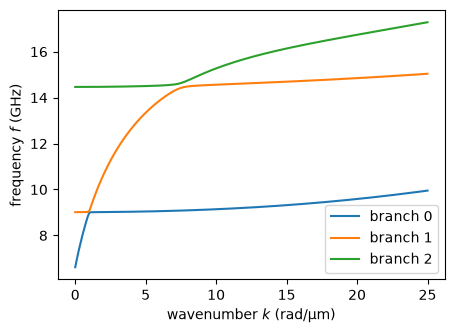

In [2]:
mat = SWT.NiFe
d = 100e-9  # (m) layer thickness
Bext = 50e-3  # (T) external magnetic field
theta, phi = np.pi/2, np.pi/2  # (rad) in-plane M, DE geometry
k = np.linspace(0, 25e6, 200) + 1  # (rad/m) SW wavenumber
N = 6  # number of thickness modes in the basis
nmodes = 3  # number of modes to plot

sln = SWT.SingleLayerNumeric(Bext, mat, d, k, theta, phi, N=N)
w, v = sln.GetDispersion()  # eigenfrequencies and eigenvectors
f = w/(2e9*np.pi)  # (GHz)

fig = plt.figure(figsize=(5, 3.5))
for n in range(nmodes):
    plt.plot(k*1e-6, f[n], label=f"branch {n}")
plt.xlabel(r"wavenumber $k$ (rad/µm)")
plt.ylabel(r"frequency $f$ (GHz)")
plt.legend(loc="lower right")
plt.show()

The modes are sorted by frequency, so we call them *branches*.  The steep DE mode starts as
the lowest branch, but soon runs into the first perpendicular standing spin wave (PSSW) at
about 1 rad/µm and into the second one at about 8 rad/µm.  Instead of crossing, the modes
hybridize and the DE character is handed over from branch 0 to branch 1 and then to branch 2.
The mode profiles will show this.

## From eigenvectors to mode profiles

The eigenvectors `v` have the shape `(2*N, N, len(k))`: for each branch and wavenumber, they
contain the amplitudes of the $N$ thickness modes of the basis.  For the unpinned boundary
conditions (the default `boundary_cond=1`), these are $\cos(n \pi z / d)$, where the uniform
mode ($n = 0$) is weighted by $1/\sqrt{2}$.  The even entries (`v[0], v[2], ...`) belong to the
out-of-plane (OOP) and the odd entries (`v[1], v[3], ...`) to the in-plane (IP) component of
the dynamic magnetization:

$$m_\mathrm{OOP}(z) = \sum_{n=0}^{N-1} v_{2n}\, \psi_n(z), \qquad
m_\mathrm{IP}(z) = \sum_{n=0}^{N-1} v_{2n+1}\, \psi_n(z), \qquad
\psi_n(z) = \frac{\cos(n \pi z / d)}{\sqrt{1 + \delta_{n0}}}.$$

The sign of an eigenvector is arbitrary, so we choose it such that the OOP component is
positive where it is largest.

In [3]:
def mode_profile(v, z, d):
    # OOP and IP profiles for eigenvectors `v` with shape (2*N, ...)
    n = np.arange(v.shape[0]//2)
    psi = np.cos(np.outer(n, z)*np.pi/d)  # basis functions, (N, Nz)
    psi[0] /= np.sqrt(2)
    oop = np.einsum("n...,nz->...z", v[0::2], psi)
    ip = np.einsum("n...,nz->...z", v[1::2], psi)
    # fix the arbitrary sign: OOP positive at its maximum
    imax = np.argmax(np.abs(oop), axis=-1)[..., np.newaxis]
    sign = np.sign(np.take_along_axis(oop, imax, axis=-1))
    return sign*oop, sign*ip


z = np.linspace(0, d, 101)  # (m) coordinate across the thickness

## Profiles at selected wavenumbers

Let's look at all three branches at a small, an intermediate and a large wavenumber.  Solid
lines are the OOP and dashed lines the IP components.

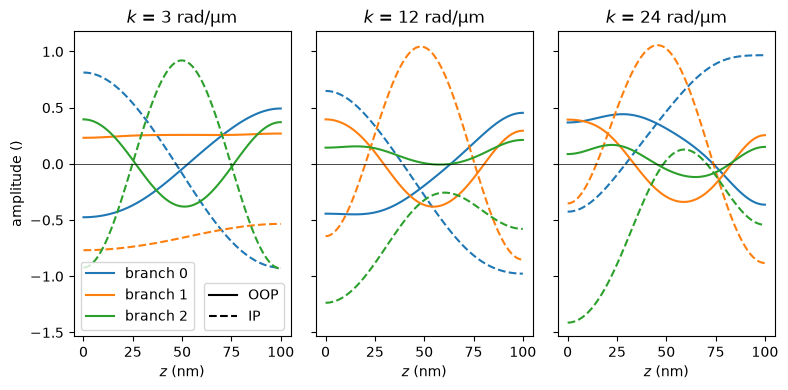

In [4]:
k_sel = [3e6, 12e6, 24e6]  # (rad/m)

fig, axs = plt.subplots(1, 3, figsize=(8, 4), sharey=True)
for ax, ks in zip(axs, k_sel):
    i = np.argmin(np.abs(k - ks))
    oop, ip = mode_profile(v[:, :nmodes, i], z, d)
    for n in range(nmodes):
        line, = ax.plot(z*1e9, oop[n], label=f"branch {n}")
        ax.plot(z*1e9, ip[n], "--", color=line.get_color())
    ax.set_title(f"$k$ = {k[i]*1e-6:.0f} rad/µm")
    ax.set_xlabel(r"$z$ (nm)")
    ax.axhline(0, color="k", lw=0.5, ls="-")
axs[0].set_ylabel("amplitude ()")
axs[0].add_artist(axs[0].legend(loc="lower left"))
styles = [Line2D([], [], color="k", ls=ls) for ls in ("-", "--")]
axs[0].legend(styles, ["OOP", "IP"], loc="lower right")
plt.tight_layout()
plt.show()

At 3 rad/µm, branch 1 is the DE mode: its amplitude is almost uniform across the film, while
branches 0 and 2 are the first and second PSSW with one and two nodes.  At 24 rad/µm, the DE
mode has moved to branch 2, and its IP component is concentrated at one of the surfaces
(here $z = 0$) – the well-known surface character of DE waves at large $kd$.  Generally, the IP
amplitude is larger than the OOP one, as the precession in an in-plane magnetized film is
elliptical.

## Transitions of the mode character

Finally, we calculate the profiles for all wavenumbers at once and plot the precession
amplitude $m_\mathrm{IP}^2 + m_\mathrm{OOP}^2$ across the thickness for each branch.  The
eigenvectors are normalized as $\sum_j v_j^2 = 1$, i.e.
$\frac{2}{d}\int_0^d (m_\mathrm{IP}^2 + m_\mathrm{OOP}^2)\,\mathrm{d}z = 1$ for every branch and
wavenumber, so a larger maximum reflects a stronger localization and a higher ellipticity of
the precession.

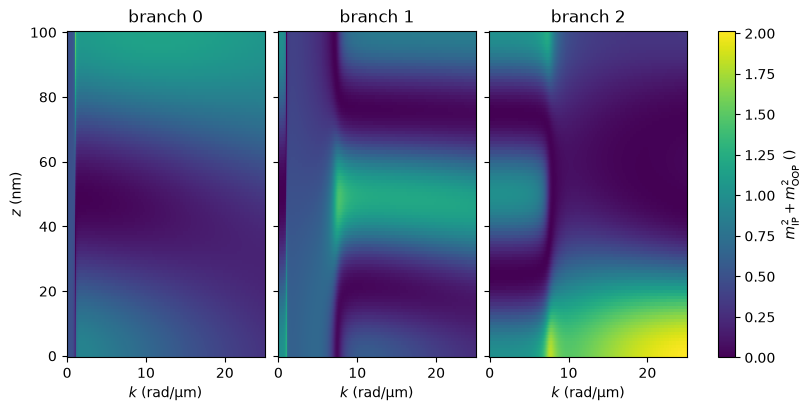

In [5]:
oop, ip = mode_profile(v[:, :nmodes], z, d)  # shape (nmodes, len(k), Nz)
amp = oop**2 + ip**2
vmin, vmax = np.min(amp), np.max(amp)

fig, axs = plt.subplots(1, 3, figsize=(8, 4), sharey=True,
                        layout="constrained")
for n, ax in enumerate(axs):
    mesh = ax.pcolormesh(k*1e-6, z*1e9, amp[n].T, shading="auto",
                         vmin=vmin, vmax=vmax)
    ax.set_title(f"branch {n}")
    ax.set_xlabel(r"$k$ (rad/µm)")
axs[0].set_ylabel(r"$z$ (nm)")
fig.colorbar(mesh, ax=axs, label=r"$m_\mathrm{IP}^2 + m_\mathrm{OOP}^2$ ()")
plt.show()

The avoided crossings at about 1 and 8 rad/µm appear as abrupt changes of the profiles: the
nearly uniform DE profile jumps from branch 0 to branch 1 and then to branch 2, where it
gradually localizes at the surface $z = 0$.  The PSSW profiles with nodes are handed down to the
lower branches in turn.